# Demand Forecasting

Build and evaluate demand forecasting models using historical warehouse demand data.

The objective is to learn temporal demand patterns and predict future product demand for inventory and replenishment decisions.

## 3.1 Load and Inspect Historical Demand Data

In this step, we load the historical demand dataset generated in Phase 2 and prepare it for forecasting.

Objectives:
- Load the historical demand data
- Convert the date column to datetime format
- Sort the data chronologically
- Check the dataset shape, columns, data types, missing values, date range, and number of products

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load historical demand data
df = pd.read_csv("../data/historical_demand.csv")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values(["product_id", "date"]).reset_index(drop=True)

df.head()

,date,product_id,actual_demand
0,2025-01-01,P001,3
1,2025-01-02,P001,4
2,2025-01-03,P001,4
3,2025-01-04,P001,2
4,2025-01-05,P001,2


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDate range:")
print(df["date"].min(), "->", df["date"].max())

print("\nNumber of products:")
print(df["product_id"].nunique())

Shape: (3650, 3)

Columns:
['date', 'product_id', 'actual_demand']

Data types:
date             datetime64[ns]
product_id               object
actual_demand             int64
dtype: object

Missing values:
date             0
product_id       0
actual_demand    0
dtype: int64

Date range:
2025-01-01 00:00:00 -> 2025-12-31 00:00:00

Number of products:
10


## 3.2 Select a Single Product Time Series

To understand the forecasting workflow clearly, we start by analyzing one product individually.

We select product `P001` and inspect its historical demand before building forecasting models.

Objectives:
- Filter the dataset for one product
- Verify the available date range
- Inspect basic demand statistics

In [3]:
product_id = "P001"

product_df = df[
    df["product_id"] == product_id
].copy()

product_df.head()

,date,product_id,actual_demand
0,2025-01-01,P001,3
1,2025-01-02,P001,4
2,2025-01-03,P001,4
3,2025-01-04,P001,2
4,2025-01-05,P001,2


In [4]:
print("Shape:", product_df.shape)

print("\nDate range:")
print(product_df["date"].min(), "->", product_df["date"].max())

print("\nDemand statistics:")
print(product_df["actual_demand"].describe())

Shape: (365, 3)

Date range:
2025-01-01 00:00:00 -> 2025-12-31 00:00:00

Demand statistics:
count    365.000000
mean       4.449315
std        1.155865
min        2.000000
25%        4.000000
50%        4.000000
75%        5.000000
max        8.000000
Name: actual_demand, dtype: float64


## 3.3 Visualize Demand Over Time

Before training a forecasting model, we visualize the historical demand of product `P001`.

This helps us inspect:
- Daily demand fluctuations
- Possible trend over time
- Seasonal or recurring patterns
- Overall demand behavior

A visual inspection is useful before building any forecasting model because it helps us understand the structure of the time series.

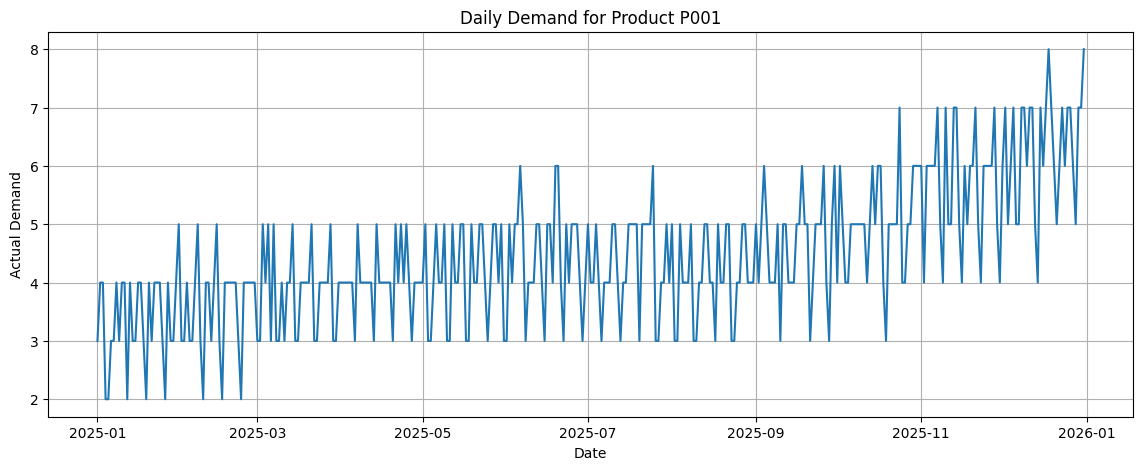

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(
    product_df["date"],
    product_df["actual_demand"]
)

plt.title("Daily Demand for Product P001")
plt.xlabel("Date")
plt.ylabel("Actual Demand")
plt.grid(True)

plt.show()

## 3.4 Inspect the Trend with a 7-Day Rolling Average

Daily demand can fluctuate from one day to another, making the overall pattern difficult to see.

To smooth short-term variation, we calculate a 7-day rolling average.

Objectives:
- Smooth daily demand fluctuations
- Make the underlying trend easier to observe
- Compare raw demand with smoothed demand

In [6]:
product_df["rolling_mean_7d"] = (
    product_df["actual_demand"]
    .rolling(window=7)
    .mean()
)

product_df.head(10)

,date,product_id,actual_demand,rolling_mean_7d
0,2025-01-01,P001,3,NaN
1,2025-01-02,P001,4,NaN
2,2025-01-03,P001,4,NaN
3,2025-01-04,P001,2,NaN
4,2025-01-05,P001,2,NaN
5,2025-01-06,P001,3,NaN
6,2025-01-07,P001,3,3.000000
7,2025-01-08,P001,4,3.142857
8,2025-01-09,P001,3,3.000000
9,2025-01-10,P001,4,3.000000


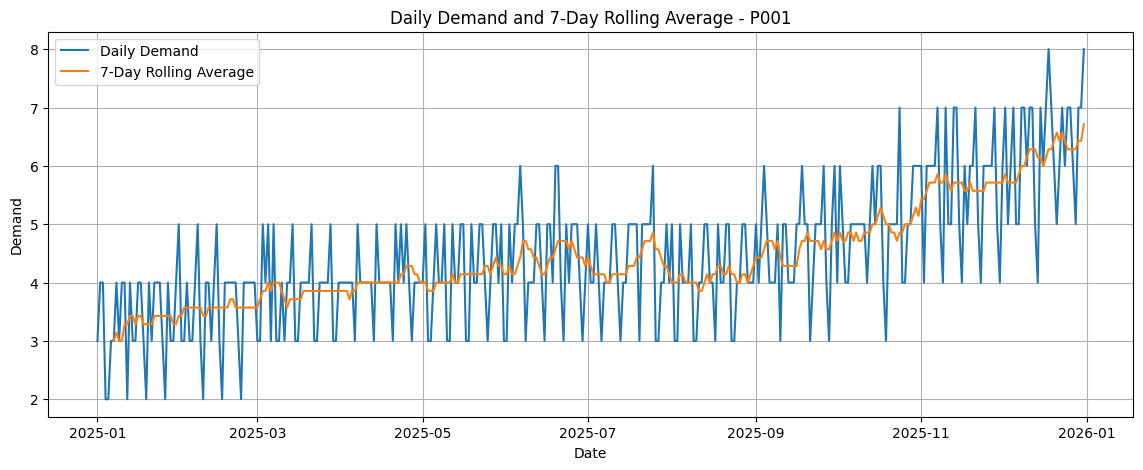

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(
    product_df["date"],
    product_df["actual_demand"],
    label="Daily Demand"
)

plt.plot(
    product_df["date"],
    product_df["rolling_mean_7d"],
    label="7-Day Rolling Average"
)

plt.title("Daily Demand and 7-Day Rolling Average - P001")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

## 3.4 Inspect the Trend with a 7-Day Rolling Average

Daily demand can fluctuate from one day to another, making the overall pattern difficult to see.

To smooth short-term variation, we calculate a 7-day rolling average.

Objectives:
- Smooth daily demand fluctuations
- Make the underlying trend easier to observe
- Compare raw demand with smoothed demand

In [8]:
split_index = int(len(product_df) * 0.8)

train = product_df.iloc[:split_index].copy()
test = product_df.iloc[split_index:].copy()

print("Training set:", train.shape)
print("Test set:", test.shape)

print("\nTraining period:")
print(train["date"].min(), "->", train["date"].max())

print("\nTest period:")
print(test["date"].min(), "->", test["date"].max())

Training set: (292, 4)
Test set: (73, 4)

Training period:
2025-01-01 00:00:00 -> 2025-10-19 00:00:00

Test period:
2025-10-20 00:00:00 -> 2025-12-31 00:00:00


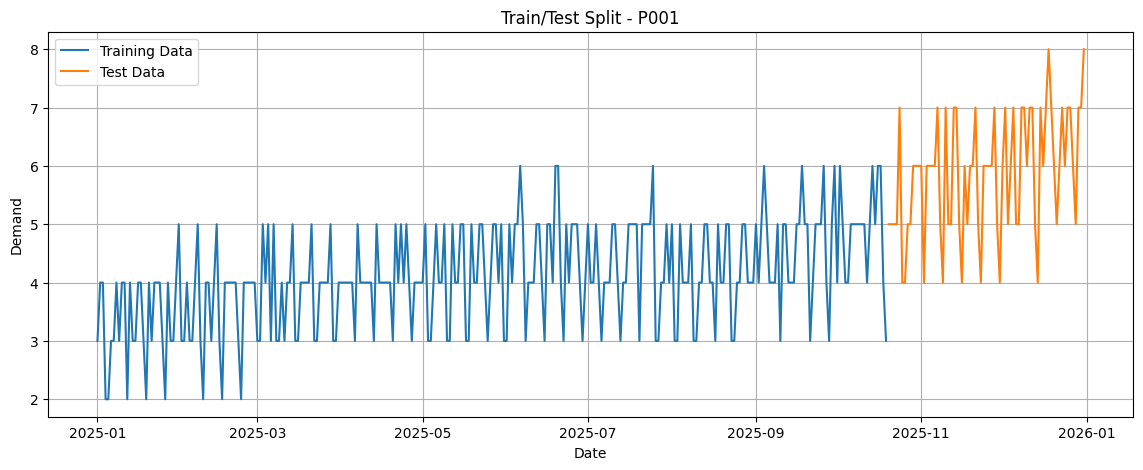

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(
    train["date"],
    train["actual_demand"],
    label="Training Data"
)

plt.plot(
    test["date"],
    test["actual_demand"],
    label="Test Data"
)

plt.title("Train/Test Split - P001")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

## 3.6 Build a Naive Baseline Forecast

Before training more advanced forecasting models, we create a simple baseline.

The naive forecasting method assumes that tomorrow's demand will be similar to the most recently observed demand.

This baseline provides a reference point for evaluating future machine-learning models.

Objectives:
- Build a simple one-step-ahead forecast
- Use the previous day's demand as the prediction
- Create a benchmark that more advanced models should outperform

In [10]:
test = test.copy()

previous_demand = pd.concat([
    train["actual_demand"].tail(1),
    test["actual_demand"].iloc[:-1]
])

test["naive_forecast"] = previous_demand.values

test[["date", "actual_demand", "naive_forecast"]].head(10)

,date,actual_demand,naive_forecast
292,2025-10-20,5,3
293,2025-10-21,5,5
294,2025-10-22,5,5
295,2025-10-23,5,5
296,2025-10-24,7,5
297,2025-10-25,4,7
298,2025-10-26,4,4
299,2025-10-27,5,4
300,2025-10-28,5,5
301,2025-10-29,6,5


### Visual Comparison: Actual Demand vs Naive Forecast

The actual test demand is compared with the naive predictions to visually inspect how closely the baseline follows demand changes.

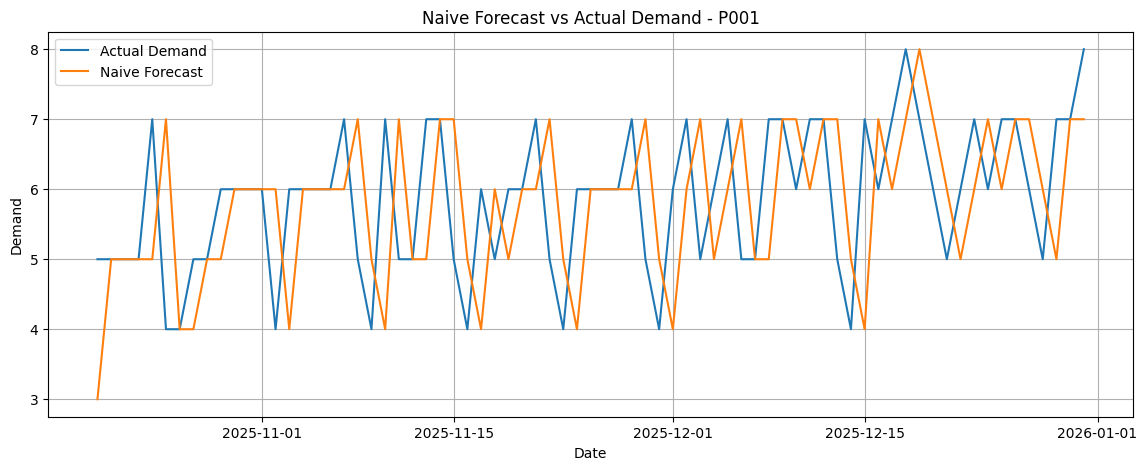

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    test["date"],
    test["actual_demand"],
    label="Actual Demand"
)

plt.plot(
    test["date"],
    test["naive_forecast"],
    label="Naive Forecast"
)

plt.title("Naive Forecast vs Actual Demand - P001")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

## 3.7 Evaluate the Naive Forecast

Visual inspection alone is not enough to judge forecasting performance.

We calculate numerical error metrics to measure the difference between the actual demand and the predicted demand.

We use:
- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error

These metrics will later help us compare the naive baseline with machine-learning forecasting models.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    test["actual_demand"],
    test["naive_forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["actual_demand"],
        test["naive_forecast"]
    )
)

print("Naive Forecast MAE:", round(mae, 3))
print("Naive Forecast RMSE:", round(rmse, 3))

Naive Forecast MAE: 1.027
Naive Forecast RMSE: 1.329


## 3.8 Create Lag Features for Machine Learning

Machine-learning models such as Linear Regression do not automatically understand time-series order.

To provide historical context, we create lag features using previous demand values.

Lag features represent demand from earlier days and allow the model to learn relationships between past and current demand.

We create:
- `lag_1`: demand from the previous day
- `lag_2`: demand from two days earlier
- `lag_7`: demand from seven days earlier

These features will be used as inputs to predict the current day's demand.

In [13]:
ml_df = product_df.copy()

ml_df["lag_1"] = ml_df["actual_demand"].shift(1)
ml_df["lag_2"] = ml_df["actual_demand"].shift(2)
ml_df["lag_7"] = ml_df["actual_demand"].shift(7)

ml_df.head(10)

,date,product_id,actual_demand,rolling_mean_7d,lag_1,lag_2,lag_7
0,2025-01-01,P001,3,NaN,NaN,NaN,NaN
1,2025-01-02,P001,4,NaN,3.0,NaN,NaN
2,2025-01-03,P001,4,NaN,4.0,3.0,NaN
3,2025-01-04,P001,2,NaN,4.0,4.0,NaN
4,2025-01-05,P001,2,NaN,2.0,4.0,NaN
5,2025-01-06,P001,3,NaN,2.0,2.0,NaN
6,2025-01-07,P001,3,3.000000,3.0,2.0,NaN
7,2025-01-08,P001,4,3.142857,3.0,3.0,3.0
8,2025-01-09,P001,3,3.000000,4.0,3.0,4.0
9,2025-01-10,P001,4,3.000000,3.0,4.0,4.0


In [14]:
ml_df = ml_df.dropna().reset_index(drop=True)

print("Shape after creating lag features:", ml_df.shape)

ml_df.head()

Shape after creating lag features: (358, 7)


,date,product_id,actual_demand,rolling_mean_7d,lag_1,lag_2,lag_7
0,2025-01-08,P001,4,3.142857,3.0,3.0,3.0
1,2025-01-09,P001,3,3.000000,4.0,3.0,4.0
2,2025-01-10,P001,4,3.000000,3.0,4.0,4.0
3,2025-01-11,P001,4,3.285714,4.0,3.0,2.0
4,2025-01-12,P001,2,3.285714,4.0,4.0,2.0


## 3.9 Train a Linear Regression Forecasting Model

After creating lag features, we can train a machine-learning model.

The lag columns are used as input features, while `actual_demand` is the target variable that the model should predict.

To avoid using future information during training, we split the transformed dataset chronologically into training and test sets.

Objectives:
- Define the input features `X`
- Define the target variable `y`
- Preserve chronological order
- Train a Linear Regression model
- Generate predictions on unseen test data

In [15]:
from sklearn.linear_model import LinearRegression

features = ["lag_1", "lag_2", "lag_7"]

X = ml_df[features]
y = ml_df["actual_demand"]

split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (286, 3)
X_test shape: (72, 3)
y_train shape: (286,)
y_test shape: (72,)


In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

predictions[:10]

array([5.49257802, 4.76724174, 5.43787099, 5.43787099, 4.20199422,
       3.31858533, 4.74190438, 4.79459525, 4.76724174, 4.81993261])

In [17]:
results = ml_df.iloc[split_index:].copy()

results["prediction"] = predictions

results[
    ["date", "actual_demand", "prediction"]
].head(10)

,date,actual_demand,prediction
286,2025-10-21,5,5.492578
287,2025-10-22,5,4.767242
288,2025-10-23,5,5.437871
289,2025-10-24,7,5.437871
290,2025-10-25,4,4.201994
291,2025-10-26,4,3.318585
292,2025-10-27,5,4.741904
293,2025-10-28,5,4.794595
294,2025-10-29,6,4.767242
295,2025-10-30,6,4.819933


## 3.10 Evaluate the Linear Regression Model

After generating predictions, we evaluate the Linear Regression model using the same metrics used for the naive baseline.

We calculate:
- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error

Using the same evaluation metrics allows us to compare the machine-learning model fairly against the baseline forecast.

A lower error indicates better forecasting performance.

In [18]:
lr_mae = mean_absolute_error(
    y_test,
    predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("Linear Regression MAE:", round(lr_mae, 3))
print("Linear Regression RMSE:", round(lr_rmse, 3))

Linear Regression MAE: 0.748
Linear Regression RMSE: 0.937


### Baseline vs Linear Regression

The Linear Regression model is compared against the naive baseline to determine whether the machine-learning approach provides a real forecasting improvement.

In [19]:
comparison = pd.DataFrame({
    "Model": ["Naive Baseline", "Linear Regression"],
    "MAE": [mae, lr_mae],
    "RMSE": [rmse, lr_rmse]
})

comparison

,Model,MAE,RMSE
0,Naive Baseline,1.027397,1.329332
1,Linear Regression,0.748425,0.937499


## 3.11 Visualize Linear Regression Predictions

After evaluating the model numerically, we visualize its predictions against the actual demand.

This allows us to inspect:
- How closely the model follows demand changes
- Where the model underestimates or overestimates demand
- Whether the prediction pattern is smoother than the actual demand

The visualization complements MAE and RMSE by showing the model behavior over time.

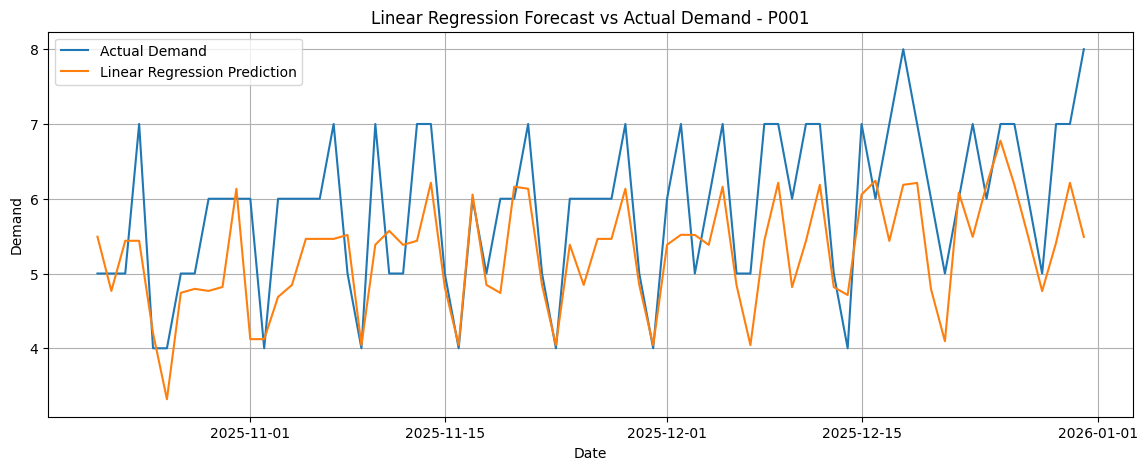

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    results["date"],
    results["actual_demand"],
    label="Actual Demand"
)

plt.plot(
    results["date"],
    results["prediction"],
    label="Linear Regression Prediction"
)

plt.title("Linear Regression Forecast vs Actual Demand - P001")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation

The Linear Regression model captures the general demand pattern better than the naive baseline, but it may still miss sudden day-to-day fluctuations.

Its lower MAE and RMSE indicate improved forecasting accuracy, while the visual comparison helps identify remaining errors.

## 3.12 Train a Random Forest Regressor

Linear Regression assumes a relatively simple relationship between the lag features and demand.

To capture more complex and non-linear relationships, we train a Random Forest Regressor.

Random Forest combines many decision trees and averages their predictions to produce a more robust forecast.

Objectives:
- Train a non-linear machine-learning model
- Use the same lag features as Linear Regression
- Generate predictions on the same test set
- Compare its performance with the baseline and Linear Regression

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([4.70910931, 4.93724901, 5.00166667, 5.00166667, 4.67428485,
       3.01625397, 4.72909546, 4.82715995, 4.93724901, 4.5167129 ])

### Evaluate the Random Forest Model

The Random Forest predictions are evaluated using the same MAE and RMSE metrics used for the previous models.

Using identical metrics and the same test period allows a fair comparison between all forecasting approaches.

In [22]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest MAE:", round(rf_mae, 3))
print("Random Forest RMSE:", round(rf_rmse, 3))

Random Forest MAE: 1.21
Random Forest RMSE: 1.48


In [23]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        lr_rmse,
        rf_rmse
    ]
})

model_comparison

,Model,MAE,RMSE
0,Naive Baseline,1.027397,1.329332
1,Linear Regression,0.748425,0.937499
2,Random Forest,1.209741,1.479636


### Model Comparison Interpretation

Among the tested approaches, Linear Regression achieved the lowest MAE and RMSE on the test set.

The Random Forest model did not outperform the simpler Linear Regression model in this experiment.

This demonstrates that a more complex model is not always more accurate. Model performance depends on the structure of the data, feature quality, hyperparameters, and the amount of available training data.

For the current P001 experiment, Linear Regression provides the strongest forecasting performance among the tested models.

## 3.13 Interpret Feature Importance

After training the Random Forest model, we inspect the importance of each lag feature.

Feature importance helps us understand which historical demand values contributed most to the model's predictions.

We compare:
- `lag_1`: demand from the previous day
- `lag_2`: demand from two days earlier
- `lag_7`: demand from seven days earlier

This step improves model interpretability and helps us understand the temporal patterns learned by the model.

In [24]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,lag_7,0.774531
0,lag_1,0.114695
1,lag_2,0.110774


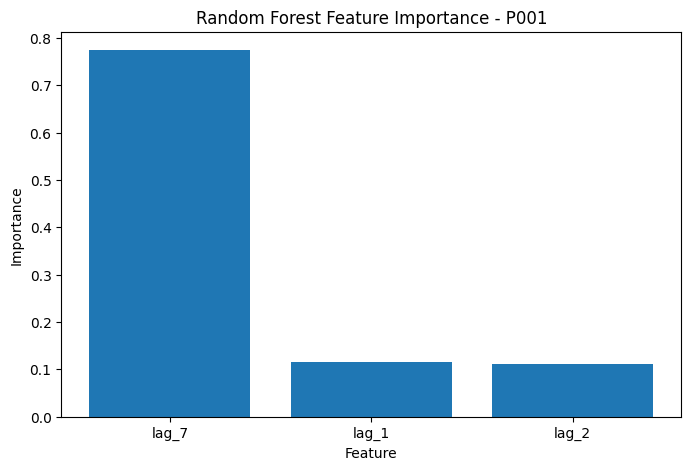

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance - P001")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.show()

### Feature Importance Interpretation

The Random Forest model relied heavily on `lag_7`, indicating that demand from seven days earlier was the most influential feature in its predictions.

This is consistent with the weekly demand patterns introduced during synthetic data generation.

However, feature importance describes how the Random Forest used the available features and does not imply causality.

## 3.14 Forecast Future Demand

After selecting Linear Regression as the best-performing model, we retrain it using all available historical data.

We then forecast the next 14 days recursively.

Each future prediction is added to the demand history so that it can be used as a lag value for the following predictions.

In [26]:
final_model = LinearRegression()

X_full = ml_df[features]
y_full = ml_df["actual_demand"]

final_model.fit(X_full, y_full)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
forecast_days = 14

history = product_df["actual_demand"].tolist()

future_dates = pd.date_range(
    start=product_df["date"].max() + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

future_predictions = []

In [30]:
for future_date in future_dates:

    lag_1 = history[-1]
    lag_2 = history[-2]
    lag_7 = history[-7]

    future_features = pd.DataFrame(
        [[lag_1, lag_2, lag_7]],
        columns=features
    )

    prediction = final_model.predict(future_features)[0]

    prediction = max(0, prediction)

    future_predictions.append(prediction)

    history.append(prediction)

In [31]:
future_forecast = pd.DataFrame({
    "date": future_dates,
    "forecast_demand": future_predictions
})

future_forecast["forecast_units"] = (
    future_forecast["forecast_demand"]
    .round()
    .astype(int)
)

future_forecast

,date,forecast_demand,forecast_units
0,2026-01-01,6.922278,7
1,2026-01-02,6.880886,7
2,2026-01-03,6.056123,6
3,2026-01-04,5.219498,5
4,2026-01-05,6.607964,7
5,2026-01-06,6.687892,7
6,2026-01-07,7.534541,8
7,2026-01-08,6.801716,7
8,2026-01-09,6.752035,7
9,2026-01-10,6.079544,6


## 3.15 Visualize Historical Demand and Future Forecast

To better understand the final forecasting output, we visualize the recent historical demand together with the 14-day future forecast.

This helps us distinguish between:
- Observed historical demand
- Model-generated future predictions

The visualization provides a clear view of how the forecast continues beyond the available historical data.

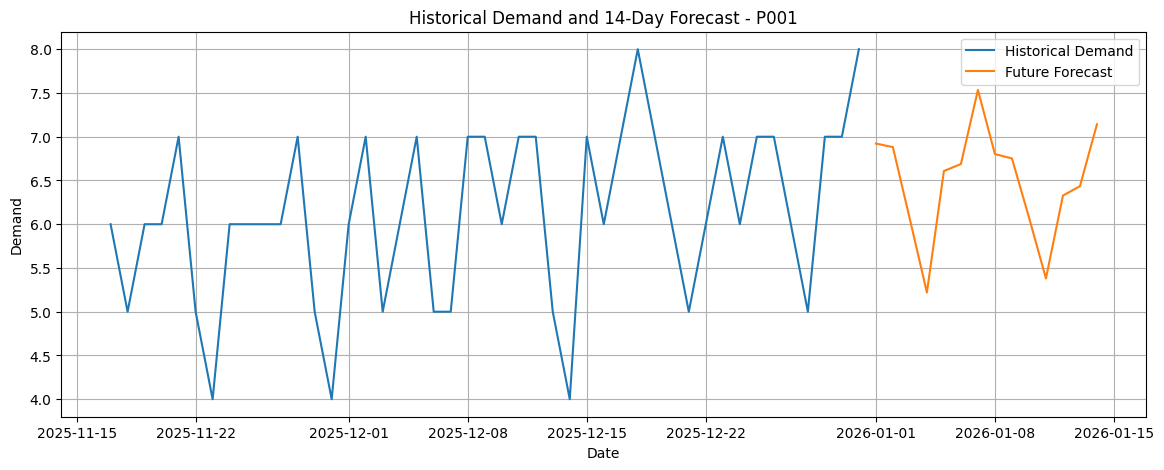

In [32]:
recent_history = product_df.tail(45)

plt.figure(figsize=(14, 5))

plt.plot(
    recent_history["date"],
    recent_history["actual_demand"],
    label="Historical Demand"
)

plt.plot(
    future_forecast["date"],
    future_forecast["forecast_demand"],
    label="Future Forecast"
)

plt.title("Historical Demand and 14-Day Forecast - P001")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)

plt.show()

### Forecast Interpretation

The model forecasts demand for the first 14 days of 2026 using the historical patterns learned from 2025.

The future values are predictions rather than observed demand and should therefore be treated as estimates.

These forecasts can later be used as inputs for inventory replenishment and stock decision-making.

## 3.16 Forecast Demand for All Products

After validating the forecasting workflow on product `P001`, we extend the same process to all products in the dataset.

For each product, we:
- Create lag features
- Train a Linear Regression model using all available historical data
- Forecast the next 14 days recursively
- Store the results in a single combined DataFrame

This transforms the single-product experiment into a warehouse-level forecasting pipeline.

In [33]:
all_forecasts = []

for product_id in df["product_id"].unique():

    product_data = (
        df[df["product_id"] == product_id]
        .copy()
        .sort_values("date")
        .reset_index(drop=True)
    )

    product_data["lag_1"] = product_data["actual_demand"].shift(1)
    product_data["lag_2"] = product_data["actual_demand"].shift(2)
    product_data["lag_7"] = product_data["actual_demand"].shift(7)

    product_ml = product_data.dropna().copy()

    X_product = product_ml[features]
    y_product = product_ml["actual_demand"]

    product_model = LinearRegression()
    product_model.fit(X_product, y_product)

    history = product_data["actual_demand"].tolist()

    future_dates = pd.date_range(
        start=product_data["date"].max() + pd.Timedelta(days=1),
        periods=14,
        freq="D"
    )

    future_predictions = []

    for future_date in future_dates:

        lag_1 = history[-1]
        lag_2 = history[-2]
        lag_7 = history[-7]

        future_features = pd.DataFrame(
            [[lag_1, lag_2, lag_7]],
            columns=features
        )

        prediction = product_model.predict(future_features)[0]
        prediction = max(0, prediction)

        future_predictions.append(prediction)
        history.append(prediction)

    product_forecast = pd.DataFrame({
        "date": future_dates,
        "product_id": product_id,
        "forecast_demand": future_predictions
    })

    all_forecasts.append(product_forecast)

In [34]:
all_forecasts_df = pd.concat(
    all_forecasts,
    ignore_index=True
)

all_forecasts_df["forecast_units"] = (
    all_forecasts_df["forecast_demand"]
    .round()
    .astype(int)
)

print("Forecast shape:", all_forecasts_df.shape)

all_forecasts_df.head(20)

Forecast shape: (140, 4)


,date,product_id,forecast_demand,forecast_units
0,2026-01-01,P001,6.922278,7
1,2026-01-02,P001,6.880886,7
2,2026-01-03,P001,6.056123,6
3,2026-01-04,P001,5.219498,5
4,2026-01-05,P001,6.607964,7
5,2026-01-06,P001,6.687892,7
6,2026-01-07,P001,7.534541,8
7,2026-01-08,P001,6.801716,7
8,2026-01-09,P001,6.752035,7
9,2026-01-10,P001,6.079544,6


## 3.17 Summarize the 14-Day Forecast per Product

The detailed forecast contains one row per product and per future day.

To support inventory decisions, we summarize the 14-day forecast for each product.

For every product, we calculate:
- Total forecast demand over the next 14 days
- Average daily forecast demand
- Maximum expected daily demand

This summary provides a compact view of expected demand before the replenishment phase.

In [36]:
forecast_summary = (
    all_forecasts_df
    .groupby("product_id")
    .agg(
        total_forecast_14d=("forecast_demand", "sum"),
        avg_daily_forecast=("forecast_demand", "mean"),
        max_daily_forecast=("forecast_demand", "max")
    )
    .reset_index()
)

forecast_summary

,product_id,total_forecast_14d,avg_daily_forecast,max_daily_forecast
0,P001,90.826951,6.487639,7.534541
1,P002,265.887143,18.991939,22.793280
2,P003,157.897562,11.278397,12.759927
3,P004,60.621644,4.330117,4.758994
4,P005,128.990895,9.213635,10.423253
5,P006,99.841033,7.131502,8.374405
6,P007,37.586692,2.684764,3.416464
7,P008,199.574751,14.255339,16.229100
8,P009,80.959389,5.782814,6.568202
9,P010,164.297392,11.735528,14.572120


In [37]:
forecast_summary[
    [
        "total_forecast_14d",
        "avg_daily_forecast",
        "max_daily_forecast"
    ]
] = forecast_summary[
    [
        "total_forecast_14d",
        "avg_daily_forecast",
        "max_daily_forecast"
    ]
].round(2)

forecast_summary

,product_id,total_forecast_14d,avg_daily_forecast,max_daily_forecast
0,P001,90.83,6.49,7.53
1,P002,265.89,18.99,22.79
2,P003,157.90,11.28,12.76
3,P004,60.62,4.33,4.76
4,P005,128.99,9.21,10.42
5,P006,99.84,7.13,8.37
6,P007,37.59,2.68,3.42
7,P008,199.57,14.26,16.23
8,P009,80.96,5.78,6.57
9,P010,164.30,11.74,14.57


## 3.18 Save Forecasting Results

The forecasting outputs are saved for use in the next phase of the project.

We save:
- Daily 14-day forecasts for all products
- A summarized forecast table for each product

These files will be used as inputs for replenishment and inventory optimization.

In [38]:
all_forecasts_df.to_csv(
    "../data/future_forecasts_14d.csv",
    index=False
)

forecast_summary.to_csv(
    "../data/forecast_summary_14d.csv",
    index=False
)

print("Forecast files saved successfully.")

Forecast files saved successfully.


# Phase 4 — Replenishment Optimization

In this phase, we combine future demand forecasts with current inventory information to support replenishment decisions.

The goal is to estimate stock coverage, identify inventory risk, and recommend replenishment quantities based on expected demand.

## 4.1 Load Inventory and Forecast Summary

We start by loading:
- Current inventory information
- The 14-day forecast summary generated in Phase 3

These datasets will be combined using `product_id`.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

inventory = pd.read_csv("../data/inventory.csv")

forecast_summary = pd.read_csv(
    "../data/forecast_summary_14d.csv"
)

inventory.head()

,product_id,current_stock,reorder_point,max_stock
0,P001,12,5,30
1,P002,8,10,40
2,P003,15,8,35
3,P004,4,5,20
4,P005,20,6,30


In [40]:
print("Inventory shape:", inventory.shape)
print("Forecast summary shape:", forecast_summary.shape)

print("\nInventory columns:")
print(inventory.columns.tolist())

print("\nForecast columns:")
print(forecast_summary.columns.tolist())

print("\nMissing values in inventory:")
print(inventory.isna().sum())

print("\nMissing values in forecast summary:")
print(forecast_summary.isna().sum())

Inventory shape: (10, 4)
Forecast summary shape: (10, 4)

Inventory columns:
['product_id', 'current_stock', 'reorder_point', 'max_stock']

Forecast columns:
['product_id', 'total_forecast_14d', 'avg_daily_forecast', 'max_daily_forecast']

Missing values in inventory:
product_id       0
current_stock    0
reorder_point    0
max_stock        0
dtype: int64

Missing values in forecast summary:
product_id            0
total_forecast_14d    0
avg_daily_forecast    0
max_daily_forecast    0
dtype: int64


## 4.2 Combine Inventory with Forecast Data

To make replenishment decisions, inventory information and forecast information must be available in the same table.

We merge the two datasets using `product_id`.

This creates one row per product containing both:
- Current stock information
- Expected future demand

In [41]:
replenishment = inventory.merge(
    forecast_summary,
    on="product_id",
    how="left"
)

replenishment

,product_id,current_stock,reorder_point,max_stock,total_forecast_14d,avg_daily_forecast,max_daily_forecast
0,P001,12,5,30,90.83,6.49,7.53
1,P002,8,10,40,265.89,18.99,22.79
2,P003,15,8,35,157.90,11.28,12.76
3,P004,4,5,20,60.62,4.33,4.76
4,P005,20,6,30,128.99,9.21,10.42
5,P006,3,5,15,99.84,7.13,8.37
6,P007,7,4,12,37.59,2.68,3.42
7,P008,25,8,40,199.57,14.26,16.23
8,P009,18,5,25,80.96,5.78,6.57
9,P010,6,8,30,164.30,11.74,14.57


## 4.3 Calculate Forecasted Days of Supply

Days of Supply estimates how many days the current inventory can support based on forecasted average daily demand.

Formula:

Days of Supply = Current Stock / Average Daily Forecast

This metric helps identify products that may run out of stock soon if expected demand continues at the forecasted level.

In [42]:
replenishment["days_of_supply"] = np.where(
    replenishment["avg_daily_forecast"] > 0,
    replenishment["current_stock"] / replenishment["avg_daily_forecast"],
    np.nan
)

replenishment["days_of_supply"] = (
    replenishment["days_of_supply"]
    .round(2)
)

replenishment[
    [
        "product_id",
        "current_stock",
        "avg_daily_forecast",
        "days_of_supply"
    ]
]

,product_id,current_stock,avg_daily_forecast,days_of_supply
0,P001,12,6.49,1.85
1,P002,8,18.99,0.42
2,P003,15,11.28,1.33
3,P004,4,4.33,0.92
4,P005,20,9.21,2.17
5,P006,3,7.13,0.42
6,P007,7,2.68,2.61
7,P008,25,14.26,1.75
8,P009,18,5.78,3.11
9,P010,6,11.74,0.51


## 4.4 Classify Inventory Risk

To make stock coverage easier to interpret, we classify each product into a simple inventory risk category based on forecasted Days of Supply.

Baseline rules:
- High Risk: less than 2 days of supply
- Medium Risk: from 2 to less than 5 days
- Low Risk: 5 days or more

These thresholds are simple educational baseline rules and can later be improved using supplier lead time, service level, and business constraints.

In [43]:
def classify_inventory_risk(days):
    if pd.isna(days):
        return "No Forecast"
    elif days < 2:
        return "High Risk"
    elif days < 5:
        return "Medium Risk"
    else:
        return "Low Risk"


replenishment["inventory_risk"] = (
    replenishment["days_of_supply"]
    .apply(classify_inventory_risk)
)

replenishment[
    [
        "product_id",
        "current_stock",
        "avg_daily_forecast",
        "days_of_supply",
        "inventory_risk"
    ]
]

,product_id,current_stock,avg_daily_forecast,days_of_supply,inventory_risk
0,P001,12,6.49,1.85,High Risk
1,P002,8,18.99,0.42,High Risk
2,P003,15,11.28,1.33,High Risk
3,P004,4,4.33,0.92,High Risk
4,P005,20,9.21,2.17,Medium Risk
5,P006,3,7.13,0.42,High Risk
6,P007,7,2.68,2.61,Medium Risk
7,P008,25,14.26,1.75,High Risk
8,P009,18,5.78,3.11,Medium Risk
9,P010,6,11.74,0.51,High Risk


## 4.5 Forecast-Based Reorder Decision

The original replenishment baseline used only the current stock level and reorder point.

In this phase, we improve the decision by also considering forecasted Days of Supply.

A product is marked for replenishment when:
- Current stock is at or below the reorder point, OR
- Forecasted Days of Supply is less than 5 days

This combines current inventory status with expected future demand.

In [44]:
replenishment["needs_reorder"] = (
    (replenishment["current_stock"] <= replenishment["reorder_point"])
    |
    (replenishment["days_of_supply"] < 5)
)

replenishment[
    [
        "product_id",
        "current_stock",
        "reorder_point",
        "days_of_supply",
        "inventory_risk",
        "needs_reorder"
    ]
]

,product_id,current_stock,reorder_point,days_of_supply,inventory_risk,needs_reorder
0,P001,12,5,1.85,High Risk,True
1,P002,8,10,0.42,High Risk,True
2,P003,15,8,1.33,High Risk,True
3,P004,4,5,0.92,High Risk,True
4,P005,20,6,2.17,Medium Risk,True
5,P006,3,5,0.42,High Risk,True
6,P007,7,4,2.61,Medium Risk,True
7,P008,25,8,1.75,High Risk,True
8,P009,18,5,3.11,Medium Risk,True
9,P010,6,8,0.51,High Risk,True


## 4.6 Calculate Recommended Reorder Quantity

After identifying products that need replenishment, we estimate how many units should be ordered.

The recommendation considers:
- Current stock
- Forecasted demand over the next 14 days
- Maximum stock capacity

The reorder quantity is limited by `max_stock` to avoid recommending more inventory than the configured stock target.

In [45]:
replenishment["forecast_based_reorder_qty"] = np.where(
    replenishment["needs_reorder"],
    np.minimum(
        np.ceil(
            replenishment["total_forecast_14d"]
            - replenishment["current_stock"]
        ),
        replenishment["max_stock"] - replenishment["current_stock"]
    ),
    0
)

replenishment["forecast_based_reorder_qty"] = (
    replenishment["forecast_based_reorder_qty"]
    .clip(lower=0)
    .astype(int)
)

replenishment[
    [
        "product_id",
        "current_stock",
        "total_forecast_14d",
        "max_stock",
        "needs_reorder",
        "forecast_based_reorder_qty"
    ]
]

,product_id,current_stock,total_forecast_14d,max_stock,needs_reorder,forecast_based_reorder_qty
0,P001,12,90.83,30,True,18
1,P002,8,265.89,40,True,32
2,P003,15,157.90,35,True,20
3,P004,4,60.62,20,True,16
4,P005,20,128.99,30,True,10
5,P006,3,99.84,15,True,12
6,P007,7,37.59,12,True,5
7,P008,25,199.57,40,True,15
8,P009,18,80.96,25,True,7
9,P010,6,164.30,30,True,24


## 4.7 Assign Replenishment Priority

Since multiple products may require replenishment at the same time, we assign a priority level based on forecasted Days of Supply.

Priority rules:
- Critical: less than 1 day of supply
- High: from 1 to less than 2 days
- Medium: from 2 to less than 5 days
- Low: 5 days or more

This helps identify which products should be replenished first.

In [46]:
def assign_replenishment_priority(days):
    if pd.isna(days):
        return "Unknown"
    elif days < 1:
        return "Critical"
    elif days < 2:
        return "High"
    elif days < 5:
        return "Medium"
    else:
        return "Low"


replenishment["replenishment_priority"] = (
    replenishment["days_of_supply"]
    .apply(assign_replenishment_priority)
)

replenishment[
    [
        "product_id",
        "days_of_supply",
        "inventory_risk",
        "needs_reorder",
        "forecast_based_reorder_qty",
        "replenishment_priority"
    ]
]

,product_id,days_of_supply,inventory_risk,needs_reorder,forecast_based_reorder_qty,replenishment_priority
0,P001,1.85,High Risk,True,18,High
1,P002,0.42,High Risk,True,32,Critical
2,P003,1.33,High Risk,True,20,High
3,P004,0.92,High Risk,True,16,Critical
4,P005,2.17,Medium Risk,True,10,Medium
5,P006,0.42,High Risk,True,12,Critical
6,P007,2.61,Medium Risk,True,5,Medium
7,P008,1.75,High Risk,True,15,High
8,P009,3.11,Medium Risk,True,7,Medium
9,P010,0.51,High Risk,True,24,Critical


## 4.8 Build the Final Replenishment Decision Table

To make the replenishment results easier to use, we create a compact decision table containing the most important inventory and forecasting indicators.

The table is sorted by replenishment priority so that the most urgent products appear first.

Key decision fields include:
- Current stock
- Forecasted Days of Supply
- Inventory risk
- Reorder decision
- Recommended reorder quantity
- Replenishment priority

In [47]:
priority_order = {
    "Critical": 0,
    "High": 1,
    "Medium": 2,
    "Low": 3,
    "Unknown": 4
}

replenishment["priority_rank"] = (
    replenishment["replenishment_priority"]
    .map(priority_order)
)

decision_table = (
    replenishment[
        [
            "product_id",
            "current_stock",
            "reorder_point",
            "max_stock",
            "avg_daily_forecast",
            "days_of_supply",
            "inventory_risk",
            "needs_reorder",
            "forecast_based_reorder_qty",
            "replenishment_priority",
            "priority_rank"
        ]
    ]
    .sort_values(
        ["priority_rank", "days_of_supply"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

decision_table

,product_id,current_stock,reorder_point,max_stock,avg_daily_forecast,days_of_supply,inventory_risk,needs_reorder,forecast_based_reorder_qty,replenishment_priority,priority_rank
0,P002,8,10,40,18.99,0.42,High Risk,True,32,Critical,0
1,P006,3,5,15,7.13,0.42,High Risk,True,12,Critical,0
2,P010,6,8,30,11.74,0.51,High Risk,True,24,Critical,0
3,P004,4,5,20,4.33,0.92,High Risk,True,16,Critical,0
4,P003,15,8,35,11.28,1.33,High Risk,True,20,High,1
5,P008,25,8,40,14.26,1.75,High Risk,True,15,High,1
6,P001,12,5,30,6.49,1.85,High Risk,True,18,High,1
7,P005,20,6,30,9.21,2.17,Medium Risk,True,10,Medium,2
8,P007,7,4,12,2.68,2.61,Medium Risk,True,5,Medium,2
9,P009,18,5,25,5.78,3.11,Medium Risk,True,7,Medium,2


## 4.9 Save Replenishment Results

The final replenishment decision table is saved for use in later phases.

This output contains the most important inventory and forecasting indicators, including:
- Current stock
- Forecasted Days of Supply
- Inventory risk
- Reorder decision
- Recommended reorder quantity
- Replenishment priority

The saved file will be used as an input for simulation and decision-support visualization.

In [48]:
decision_table.to_csv(
    "../data/replenishment_decisions.csv",
    index=False
)

print("Replenishment decisions saved successfully.")

Replenishment decisions saved successfully.


In [49]:
final_decision_table = decision_table.drop(
    columns=["priority_rank"]
)

final_decision_table.to_csv(
    "../data/replenishment_decisions.csv",
    index=False
)

final_decision_table

,product_id,current_stock,reorder_point,max_stock,avg_daily_forecast,days_of_supply,inventory_risk,needs_reorder,forecast_based_reorder_qty,replenishment_priority
0,P002,8,10,40,18.99,0.42,High Risk,True,32,Critical
1,P006,3,5,15,7.13,0.42,High Risk,True,12,Critical
2,P010,6,8,30,11.74,0.51,High Risk,True,24,Critical
3,P004,4,5,20,4.33,0.92,High Risk,True,16,Critical
4,P003,15,8,35,11.28,1.33,High Risk,True,20,High
5,P008,25,8,40,14.26,1.75,High Risk,True,15,High
6,P001,12,5,30,6.49,1.85,High Risk,True,18,High
7,P005,20,6,30,9.21,2.17,Medium Risk,True,10,Medium
8,P007,7,4,12,2.68,2.61,Medium Risk,True,5,Medium
9,P009,18,5,25,5.78,3.11,Medium Risk,True,7,Medium
